<a href="https://colab.research.google.com/github/manowar077/Machine-Learning/blob/main/First_ML_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/Placement dataset.csv')
df

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0
...,...,...,...,...
95,96,4.3,200,0
96,97,4.4,42,0
97,98,6.7,182,1
98,99,6.3,103,1


In [ ]:
df.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0


In [ ]:
df.shape

(100, 3)

In [ ]:
# Steps we are going to do
#1.preprocess +EDA +Feature engneering
#2.Extract input and output cols
#3.scale the value
#4.Train the model
#5.evaluate the model/model selection
#6.Deploy the model

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGPA       100 non-null    float64
 1   IQ         100 non-null    int64  
 2   Placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


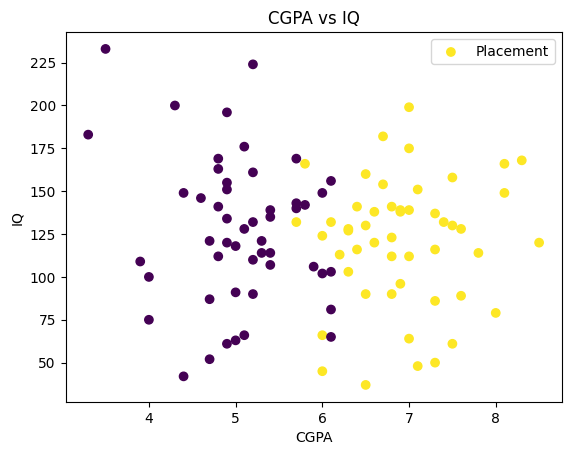

In [ ]:
df = pd.read_csv('/content/Placement dataset.csv')
df = df.iloc[:,1:]

import matplotlib.pyplot as plt
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.legend(['Placement'])
plt.title('CGPA vs IQ')
plt.show()

**We are going to use logestic regression**

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [ ]:
X

,Placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
Y

,Placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,y_teast=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train

,CGPA,IQ
82,6.5,37
72,7.3,116
87,5.7,132
93,6.8,112
55,7.8,114
...,...,...
46,5.3,114
44,7.5,61
52,7.0,175
49,5.4,135


In [ ]:
Y_train

,Placement
82,1
72,1
87,1
93,1
55,1
...,...
46,0
44,1
52,1
49,0


In [ ]:
X_test

,CGPA,IQ
43,6.8,141
36,5.7,140
19,5.2,132
29,7.0,112
95,4.3,200
94,4.7,52
62,6.0,102
68,4.0,75
97,6.7,182
24,4.7,121


In [ ]:
#scale a value
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train

array([[ 0.40095235, -2.1894946 ],
       [ 1.10506379, -0.18623806],
       [-0.30315909,  0.21948479],
       [ 0.66499414, -0.28766877],
       [ 1.54513344, -0.23695341],
       [-0.91925661, -0.82018   ],
       [ 1.28109165,  0.16876943],
       [-0.0391173 ,  0.65056531],
       [-0.21514516,  0.47306157],
       [-1.88740984, -0.3637418 ],
       [ 0.04889663,  0.21948479],
       [-0.56720088, -0.23695341],
       [ 0.04889663, -1.07375678],
       [-0.21514516,  1.08164583],
       [-1.09528447,  1.15771887],
       [-0.0391173 ,  0.01662337],
       [ 0.75300807, -0.69339161],
       [ 0.75300807,  0.39698853],
       [-1.1832984 , -0.92161071],
       [ 0.04889663,  0.82806906],
       [ 0.48896628, -0.08480734],
       [ 1.80917523,  0.65056531],
       [-0.12713123, -0.43981483],
       [-0.83124268,  0.11805408],
       [ 0.31293842,  0.44770389],
       [ 0.04889663, -1.47947962],
       [ 0.841022  ,  1.9184492 ],
       [ 0.841022  ,  0.39698853],
       [-1.00727054,

In [43]:
X_test=sc.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [44]:
X_test

array([[-13.66993894,  -3.20904448],
       [-14.33002163,  -3.2090449 ],
       [-14.63005922,  -3.2090482 ],
       [-13.54992391,  -3.20905647],
       [-15.17012688,  -3.20902009],
       [-14.93009681,  -3.20908128],
       [-14.14999908,  -3.20906061],
       [-15.35014943,  -3.20907177],
       [-13.72994646,  -3.20902753],
       [-14.93009681,  -3.20905275]])

In [45]:
#model train
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

LogisticRegression()

In [46]:
#model evaluation
model.predict(X_test)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [51]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_teast, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.7


<Axes: >

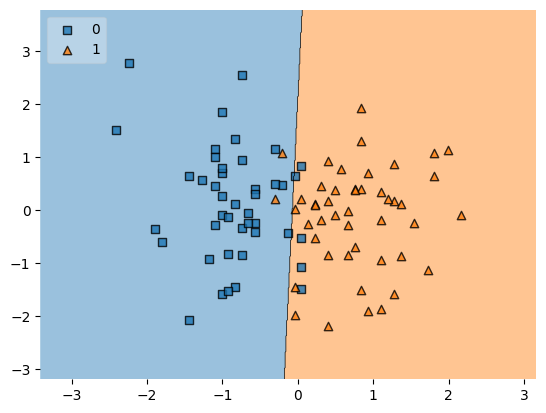

In [53]:
#how to plot design boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train,Y_train.values,clf=model,legend=2)

In [56]:
#pickle ->convert object into file so we can use in any format
import pickle
pickle.dump(model,open('model.pkl','wb'))